## Lecture session for 1) Normal Distributions and 2) Variability and Sample Means

**STATISTICS**

### 1) Normal distributions

In [1]:
#Importing libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

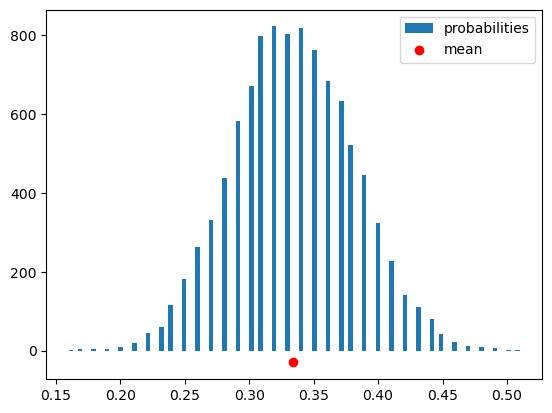

In [3]:
# Lets begin with this:
# Simulate the probability of getting a number divisible by 3 in rolling
# 50 fair dice

n=10000
result=[]
size=100  # this is the sample size

for i in range(n):
    d50=np.random.randint(1,7,size)
    divby3=np.count_nonzero(d50%3==0)
    probability=divby3/size  # this the statistical parameter under study
    result.append(probability)
mean_value = np.array(result).mean()

plt.hist(result,bins=100, label = "probabilities")

plt.scatter(mean_value, -30, marker = "o", color = "red", label = "mean")
plt.legend()
plt.show()


In [4]:
np.mean(result)

0.33391

In [5]:
np.std(result) # note: with larger sample size, SD decreases

0.0471216712352183

## Given a normal distribution, find the z-scores of individual observations

In [22]:
#### Creating a normal distribution of sleeping time of 10,000 TTU students with mean = 7 hours and standard deviation = 1.5 hours
# use the function: np.random.normal(mean,SD,size)

sleep_time = np.random.normal(7, 1.5, 10000)

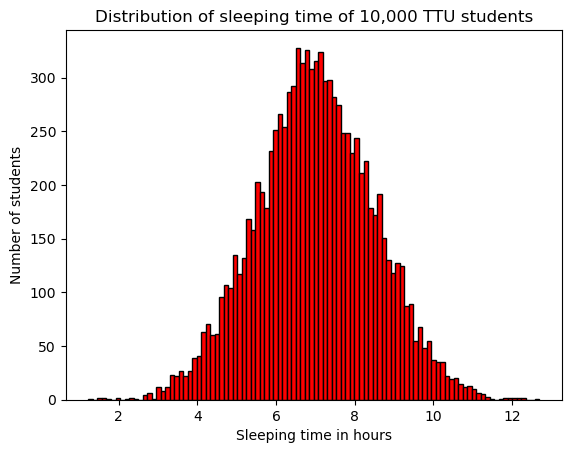

In [23]:
#Plotting the distribution of sleeping time of 10,000 TTU students

plt.hist(sleep_time, color = 'red', ec = 'black', bins = 100)
plt.xlabel('Sleeping time in hours')
plt.ylabel('Number of students')
plt.title('Distribution of sleeping time of 10,000 TTU students')
plt.show()

In [24]:
#Getting the minimum sleeping time out of 10,000 students

min_value = np.min(sleep_time)
min_value

1.2319117480290576

In [25]:
#Computing the z_score for the minimum sleeping time

z_score_min = (min_value - 7)/1.5
z_score_min

-3.8453921679806284

In [26]:
#Getting the maximum sleeping time out of 10,000 students

max_value = np.max(sleep_time)

max_value

12.695015578304492

In [27]:
#Computing the z_score for the maximum sleeping time

z_score_max = (max_value - 7)/1.5
z_score_max

3.7966770522029947

In [28]:
#Computing the z-score for te sleeping times of all 10,000 students

z_score_all = (sleep_time - 7)/1.5
z_score_all

array([ 0.96133925, -0.28995982,  0.90843604, ...,  1.3835913 ,
        2.00922812,  0.41469339])

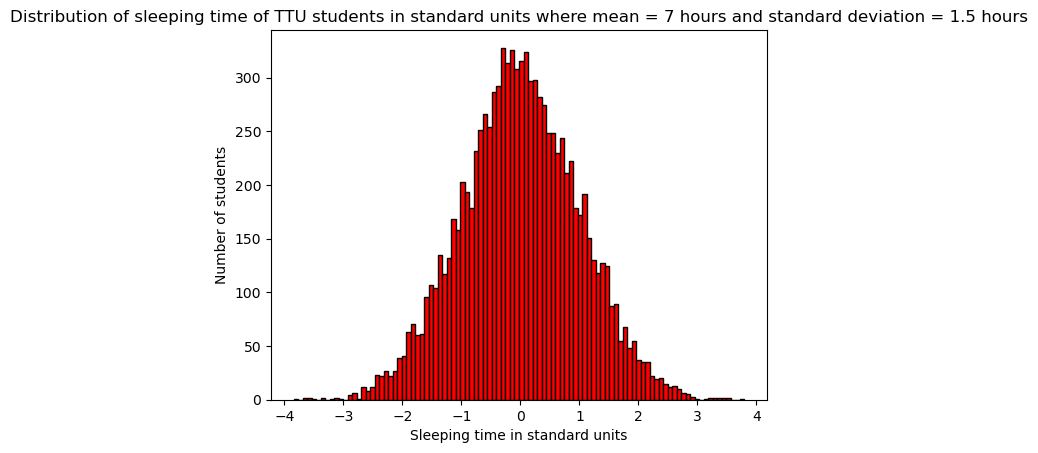

In [29]:
#Standard normal curve: Plotting the normal distribution of sleeping time in terms of z-scores

plt.hist(z_score_all, color = 'red', ec = 'black', bins = 100)
plt.xlabel('Sleeping time in standard units')
plt.ylabel('Number of students')
plt.title('Distribution of sleeping time of TTU students in standard units where mean = 7 hours and standard deviation = 1.5 hours')
plt.show()

In [30]:
#Finding the percentage of data between –3 SD and 3 SD

percent_3sd = np.count_nonzero((z_score_all > -3) & (z_score_all < 3))/10000
percent_3sd

0.9976

In [31]:
#Finding the percentage of data between –2 SD and 2 SD

percent_2sd = np.count_nonzero((z_score_all > -2) & (z_score_all < 2))/10000
percent_2sd

0.9555

In [32]:
#Finding the percentage of data between –1 SD and 1 SD

percent_1sd = np.count_nonzero((z_score_all > -1) & (z_score_all < 1))/10000
percent_1sd

0.6838

**<span style="color:red">In normal distributions:**
    
**<span style="color:red">Approximately 68% of data fall within 1 SD of the mean**
    
**<span style="color:red">Approximately 95% of data fall within 2 SD of the mean**
    
**<span style="color:red">Approximately 99.7% of data fall within 3 SD of the mean**

### CENTRAL LIMIT THEOREM

### Central limit theorem: Distribution of means from large random samples will be roughly normal, regardless of the distribution of the population from which the samples are drawn


Empirical histogram of means calculated from many random samples is always a normal distribution


In [33]:
#Reading the file that contains the population of flight delay times

flights = pd.read_csv('united_summer2015.csv')
flights.head()

,Date,Flight Number,Destination,Delay
0,6/1/15,73,HNL,257
1,6/1/15,217,EWR,28
2,6/1/15,237,STL,-3
3,6/1/15,250,SAN,0
4,6/1/15,267,PHL,64


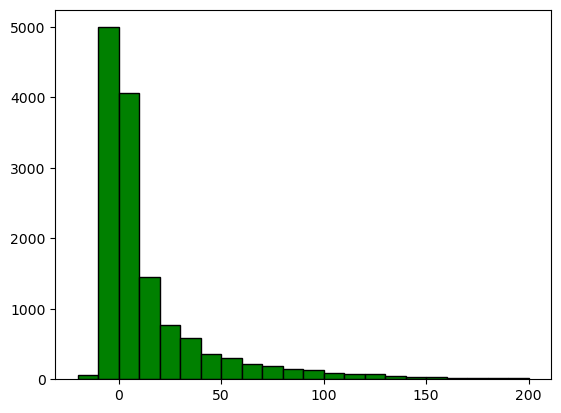

In [34]:
#Distribution of all of the flight delay times that are less than 200 minutes in the dataset (i.e., for entire population)

plt.hist('Delay', data = flights, color = 'green', ec = 'black', bins = np.arange(-20,201,10))
plt.show()

In [35]:
#Getting mean of the column 'Delay'

pop_mean_delay = flights['Delay'].mean()
pop_mean_delay

16.658155515370705

In [36]:
#Getting standard deviation of the column 'Delay'

pop_std_delay = flights['Delay'].std()
pop_std_delay

39.48162778440392

In [38]:
#Using sample() function to get a sample of size 1000 from the population dataset and computing the mean delay time for that 
#sample

sample = flights['Delay'].sample(1000, replace = True)
sample_mean_delay= np.mean(sample)
sample_mean_delay

15.807

16.658155515370705


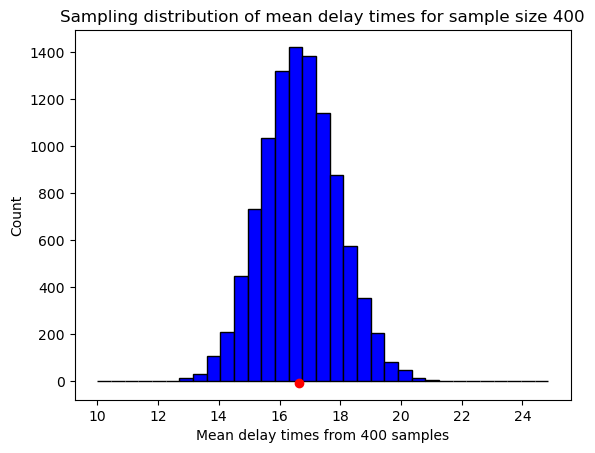

In [40]:
#Simulation of mean flight delay time for 10,000 samples of size = 400 (statistic here is mean)

#Even though random samples are drawn from a right-skewed population distribution, the sampling distribution of mean delay 
#times is roughly a normal distribution

repetitions = np.arange(1,10001)

outcomes_1000 =[]

for i in repetitions:
    sample = flights['Delay'].sample(1000, replace = True)
    sample_mean_delay = np.mean(sample)
    outcomes_1000.append(sample_mean_delay)

outcomes_1000 = np.array(outcomes_1000)
print(pop_mean_delay)

plt.hist(outcomes_1000, color = 'blue', ec = 'black', bins = np.arange(10,25,0.45))
plt.scatter(pop_mean_delay, -7, color='red')
plt.xlabel('Mean delay times from 400 samples')
plt.ylabel('Count')
plt.title('Sampling distribution of mean delay times for sample size 400')
plt.show()

**<span style="color:red">Even though random samples are drawn from a right-skewed population distribution, the sampling distribution of mean delay times is roughly a normal distribution.**

### 2) Variability and sample means

**EFFECT OF SAMPLE SIZE ON VARIABILITY**

Text(0.5, 1.0, 'Sampling distribution of proportion of purple flowers for 10,000 samples of size 200')

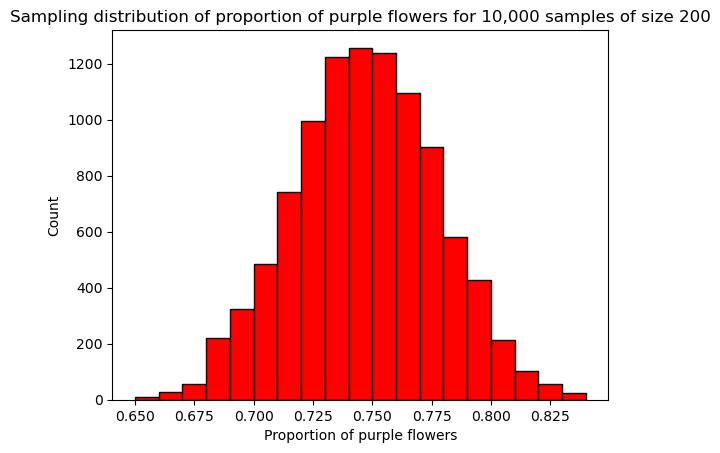

In [41]:
#Simulating the proportion of plants containing purple flowers out of 200 plants for 10,000 random samples and plotting a 
#distribution of the proportions

flowers = ['Purple', 'White']
total = 200
prop = [0.75, 0.25]

repetitions = 10000

outcomes_200 = []

for i in np.arange(repetitions):
    random_outcomes = np.random.choice(flowers, total, p=prop)
    purple_count = np.count_nonzero(random_outcomes=='Purple')
    samples_prop = purple_count/total
    outcomes_200.append(samples_prop)
    
outcomes_200 = np.array(outcomes_200)

plt.hist(outcomes_200, color='red', ec = 'black', bins = np.arange(0.65, 0.85, 0.01))
plt.xlabel('Proportion of purple flowers')
plt.ylabel('Count')
plt.title('Sampling distribution of proportion of purple flowers for 10,000 samples of size 200')

Text(0.5, 1.0, 'Sampling distribution of proportion of purple flowers for 10,000 samples of size 800')

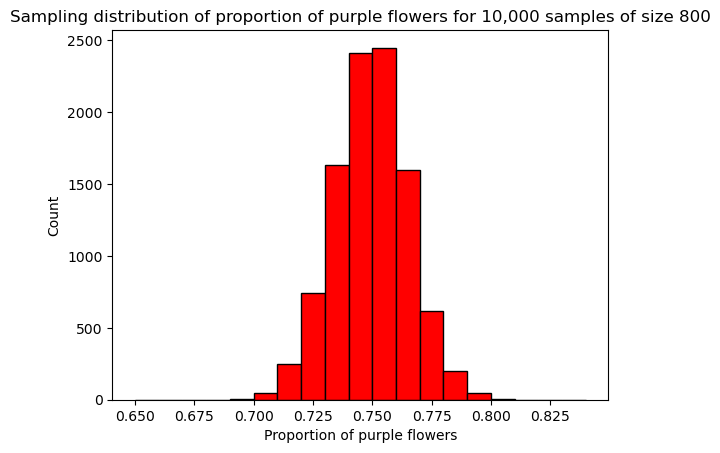

In [42]:
#Simulating the proportion of plants containing purple flowers out of 800 plants for 10,000 random samples and plotting a 
#distribution of the proportions

flowers = ['Purple', 'White']
total = 800
prop = [0.75, 0.25]

repetitions = 10000

outcomes_800 = []

for i in np.arange(repetitions):
    random_outcomes = np.random.choice(flowers, total, p=prop)
    purple_count = np.count_nonzero(random_outcomes=='Purple')
    samples_prop = purple_count/total
    outcomes_800.append(samples_prop)
    
outcomes_800 = np.array(outcomes_800)

plt.hist(outcomes_800, color='red', ec = 'black', bins = np.arange(0.65, 0.85, 0.01))
plt.xlabel('Proportion of purple flowers')
plt.ylabel('Count')
plt.title('Sampling distribution of proportion of purple flowers for 10,000 samples of size 800')

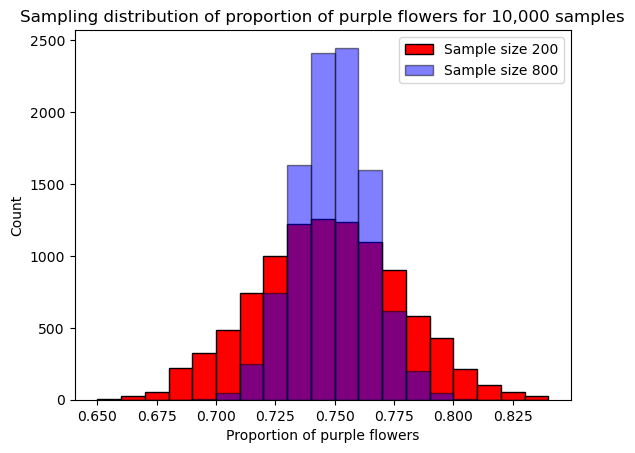

In [43]:
#Plotting an overlaid histogram displaying the distribution of the proportions for sample size 200 and 800

#Increasing the sample size makes the normal distribution narrower and taller

#Increasing the sample size decreases the variability in sample proportion

plt.hist(outcomes_200, color='red', ec = 'black', bins = np.arange(0.65, 0.85, 0.01), alpha = 1, label = 'Sample size 200')
plt.hist(outcomes_800, color='blue', ec = 'black', bins = np.arange(0.65, 0.85, 0.01), alpha = 0.5, label = 'Sample size 800')
plt.xlabel('Proportion of purple flowers')
plt.ylabel('Count')
plt.title('Sampling distribution of proportion of purple flowers for 10,000 samples')
plt.legend()

**<span style="color:red">Increasing the sample size makes the normal distribution narrower and taller**

**<span style="color:red">Increasing the sample size decreases the variability in sample proportion**

**RELATIONSHIP BETWEEN SAMPLE SIZE AND VARIABILITY**

Text(0.5, 1.0, 'Sampling distribution of mean delay times for sample size 100')

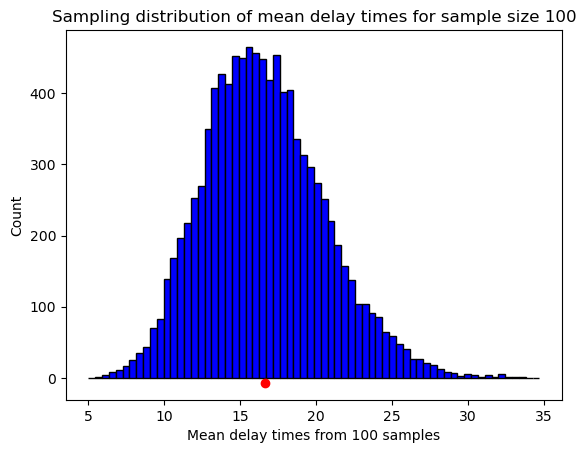

In [44]:
#Simulation of mean flight delay time for 10,000 samples of size = 100 (statistic here is mean)

repetitions = np.arange(1,10001)

outcomes_100 =[]

for i in repetitions:
    sample = flights['Delay'].sample(100, replace = True)
    sample_mean_delay = np.mean(sample)
    outcomes_100.append(sample_mean_delay)

outcomes_100 = np.array(outcomes_100)

plt.hist(outcomes_100, color = 'blue', ec = 'black', bins = np.arange(5,35,0.45))
plt.scatter(pop_mean_delay, -7, color='red')
plt.xlabel('Mean delay times from 100 samples')
plt.ylabel('Count')
plt.title('Sampling distribution of mean delay times for sample size 100')

Text(0.5, 1.0, 'Sampling distribution of mean delay times for sample size 400')

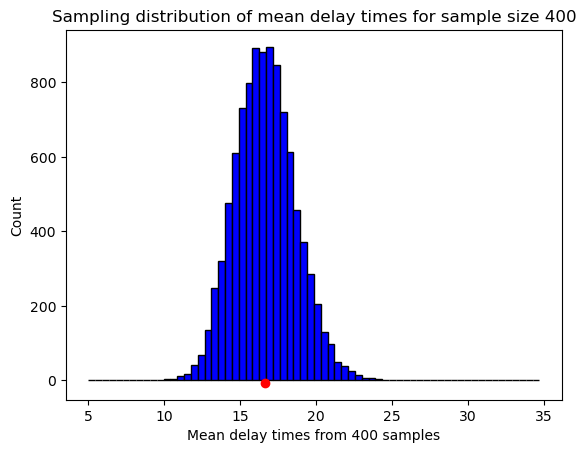

In [45]:
#Simulation of mean flight delay time for 10,000 samples of size = 400 (statistic here is mean)

repetitions = np.arange(1,10001)

outcomes_400 =[]

for i in repetitions:
    sample = flights['Delay'].sample(400, replace = True)
    sample_mean_delay = np.mean(sample)
    outcomes_400.append(sample_mean_delay)

outcomes_400 = np.array(outcomes_400)

plt.hist(outcomes_400, color = 'blue', ec = 'black', bins = np.arange(5,35,0.45))
plt.scatter(pop_mean_delay, -7, color='red')
plt.xlabel('Mean delay times from 400 samples')
plt.ylabel('Count')
plt.title('Sampling distribution of mean delay times for sample size 400')

Text(0.5, 1.0, 'Sampling distribution of mean delay times for sample size 900')

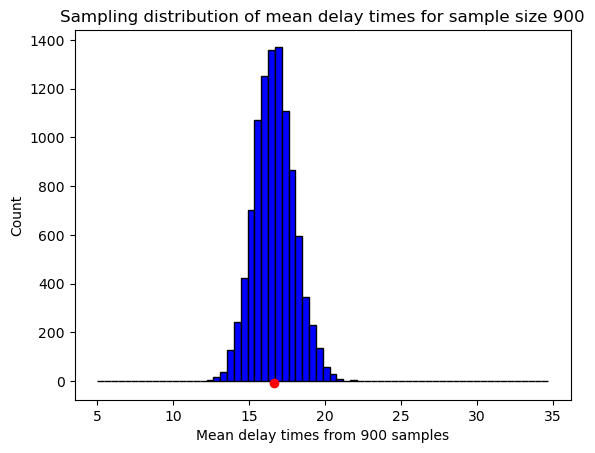

In [46]:
#Simulation of mean flight delay time for 10,000 samples of size = 900 (statistic here is mean)

repetitions = np.arange(1,10001)

outcomes_900 =[]

for i in repetitions:
    sample = flights['Delay'].sample(900, replace = True)
    sample_mean_delay = np.mean(sample)
    outcomes_900.append(sample_mean_delay)

outcomes_900 = np.array(outcomes_900)

plt.hist(outcomes_900, color = 'blue', ec = 'black', bins = np.arange(5,35,0.45))
plt.scatter(pop_mean_delay, -7, color='red')
plt.xlabel('Mean delay times from 900 samples')
plt.ylabel('Count')
plt.title('Sampling distribution of mean delay times for sample size 900')

In [47]:
#Computing the standard deviation of sample means for sample size 100, 400, and 900

sample_std_delay_100 = np.std(outcomes_100)

sample_std_delay_400 = np.std(outcomes_400)

sample_std_delay_900 = np.std(outcomes_900)

print(pop_std_delay,"\n", sample_std_delay_100, "\n",sample_std_delay_400,"\n", sample_std_delay_900)

39.48162778440392 
 3.9618027522802044 
 1.976864246447499 
 1.3179381690182763


**<span style="color:red">Relationship between sample size and variability (standard deviation) is as follows:**

**<span style="color:red">𝑆𝐷 𝑜𝑓 𝑎𝑙𝑙 𝑝𝑜𝑠𝑠𝑖𝑏𝑙𝑒 𝑠𝑎𝑚𝑝𝑙𝑒 𝑚𝑒𝑎𝑛𝑠 =  (𝑃𝑜𝑝𝑢𝑙𝑎𝑡𝑖𝑜𝑛 𝑆𝐷)/((𝑆𝑎𝑚𝑝𝑙𝑒 𝑠𝑖𝑧𝑒)<sup>1/2</sup>)**
    
**<span style="color:red">When sample size increases by a factor of K, SD decreases by a factor of square root of K**

**VERIFYING THE ACCURACY OF THE RELATIONSHIP BETWEEN SAMPLE SIZE AND VARIABILITY**

In [48]:
#Writing a general function that will take sample size 'n' as the argument and return the mean delay time for 10,000 samples of
#sample size 'n'

def sample_means_func(n):
    repetitions = np.arange(1,10001)

    outcomes =[]

    for i in repetitions:
        sample = flights['Delay'].sample(n, replace = True)
        sample_mean_delay = np.mean(sample)
        outcomes.append(sample_mean_delay)
        
    outcomes = np.array(outcomes)
    
    return outcomes

In [49]:
#Simulation of mean flight delay time for 10,000 samples of different sample sizes ranging from 50 to 900 (both inclusive)

sample_sizes = np.arange(50, 901, 50)

sd_simulation = []
sd_relation = []

for i in sample_sizes:
    sample_means = sample_means_func(i)
    sd_sample_means = np.std(sample_means)
    
    sd_simulation.append(sd_sample_means)
    sd_relation.append(pop_std_delay/(np.sqrt(i)))
    
sd_simulation = np.array(sd_simulation)
sd_relation = np.array(sd_relation)

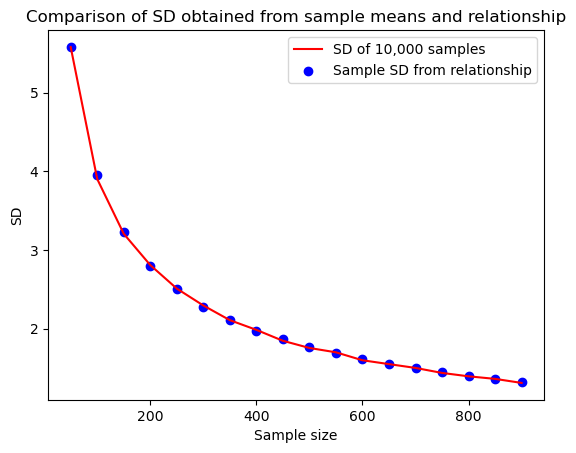

In [50]:
#Comparing the SD values obtained from different sample sizes via simulation with those obtained from the relationship

#SD from simulation and relationship are in good agreement with each other

#Variability decreases (accuracy in the value of mean delay time increases) as sample size increases

plt.plot(sample_sizes, sd_simulation, color = 'red', label = 'SD of 10,000 samples')
plt.scatter(sample_sizes, sd_relation, color = 'blue', label = 'Sample SD from relationship')
plt.xlabel('Sample size')
plt.ylabel('SD')
plt.title('Comparison of SD obtained from sample means and relationship')
plt.legend()

**<span style="color:red">SD from simulated samples and relationship are in good agreement with each other**

**<span style="color:red">Variability decreases (accuracy in the value of mean delay time increases) as sample size increases**